# Homework 4 

### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).

 
## Problem 1: Period estimation using Lomb-Scargle periodogram


Below in the notebook is the code that generates Figure 10.17 in the textbook. As it is now, it:
* downloads a dataset of variable stars collected with the [LINEAR](https://en.wikipedia.org/wiki/Lincoln_Near-Earth_Asteroid_Research) telescope,
* selects six of them (as given by the `ids` variable),
* computes the Lomb-Scargle periodogram in the `compute_best_frequencies` function,
* finds the best frequency by looking for the highest peak in the periodiogram, and
* folds the light curves and plots the results.

Either by modifying the code below, or by writing similar code, do the following:

1. Find the frequencies for the first 1000 stars in the LINEAR datasets (i.e., those with IDs in `dataAll.ids[:1000]`, where `dataAll` is the variable containing the LINEAR dataset as defined below).

2. Compute the periods corresponing to the frequencies above, and plot the histogram of periods using 50 bins in range $0 < T < 25$ hours. What do you observe in the histogram?

3. Generate four 6-panel figures analogous to Figure 10.17, for 6 stars (arbitrarily chosen) from the four easily visible peaks, respectivelly. Comment on (dis)similarities of these plots and of stars within each plot.

4. EXTRA CREDIT: compute the histogram in #2 for ALL (about 7000) stars in the data set, not just the first 1000 (note: this will take a while - on a Mac Pro several hours). Modify the histogram range and bin sizes as needed to bring out the features (clusters) in the data. Comment on differences compared to the 1000-star case. Extra credit 20% of this homework! 


### <span style="color:red">WARNING:</span>

For the astroML code below to work properly, you need to install 
numpy version 1.26. For example: conda install "numpy==1.26"



## Problem 2

PCA applied to 4-D data for variable stars from the SDSS and LINEAR surveys:

-- SDSS u-g and g-i colors,

-- LINEAR variability period (logP) and variability amplitude (A).

The code below reads the data and, to get you familar with the dataset, plots the 
g-i vs. u-g and A vs. logP diagrams.

You need to run PCA with four components and then

a) plot P2 vs. P1 diagram, and P3 vs. P1 diagram, and P3 vs. P4 diagram. Comment what insights, if any, did PCA analysis bring.

b) plot P1 vs. g-i and P1 vs. logP diagrams; repeat with P2, P3, and P4. Comment what insights, if any, did PCA analysis bring.

## Problem 3

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does PCA stand for, and what does it do?  

* What does Lomb-Scargle periodogram do?  

# Homework 4: Solutions

### Some useful definitions and functions

In [12]:
import numpy as np 
from matplotlib import pyplot as plt

# monkey-patch before importing the astroML package 
# np.recfromtxt = np.genfromtxt

from astroML.datasets import fetch_LINEAR_geneva
import pandas as pd
from astroML.decorators import pickle_results
from astroML.time_series import search_frequencies, lomb_scargle, MultiTermFit
from astroML.datasets import fetch_LINEAR_sample
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

import warnings
from astroML.utils.exceptions import AstroMLDeprecationWarning
warnings.filterwarnings("ignore", category=AstroMLDeprecationWarning)

 
%matplotlib inline

### <span style="color:red">CHECK NUMPY VERSION:</span>

It must be 1.26 

In [13]:
print(np.__version__)
print(np.__file__)

2.4.6
c:\Users\harty\miniconda3\envs\standard\Lib\site-packages\numpy\__init__.py


### Write your solutions below...

## Problem 1

In [14]:
# first we read data about LINEAR sample

# hack to account for some old numpy code in astroML
def recfromtxt_compat(*args, **kwargs):
    kwargs.setdefault("dtype", None)
    kwargs.setdefault("encoding", None)
    kwargs.setdefault("names", None)
    return np.genfromtxt(*args, **kwargs)

np.recfromtxt = recfromtxt_compat


from astroML.datasets import fetch_LINEAR_sample
dataAll = fetch_LINEAR_sample(data_home="astroML_data")  
# the number of LINEAR stars with light curves
len(dataAll.targets)

7010

In [15]:
## some helper code taken from
## https://www.astroml.org/book_figures/chapter10/fig_LINEAR_LS.html

# Figure 10.17 code
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general

#------------------------------------------------------------
# Compute the best frequencies
# @pickle_results('LINEAR_LS.pkl')
def compute_best_frequencies(df, ids, n_eval=10000, n_retry=5, generalized=True):
    results = {}
    for i in ids:
        t, y, dy = df[i].T
        print(" - computing power for %i (%i points)" % (i, len(t)))
        kwargs = dict(generalized=generalized)
        # search_frequencies() is a work horse from astroML
        omega, power = search_frequencies(t, y, dy, n_eval=n_eval,
                                          n_retry=n_retry,
                                          LS_kwargs=kwargs)
        # store the power spectrum, power(omega)
        results[i] = [omega, power]

    return results

# plot phased light curves 
def plot_lightcurves(df, results, ids):
    #------------------------------------------------------------
    # Plot the phased light-curves
    fig = plt.figure(figsize=(5, 6.5))
    fig.subplots_adjust(hspace=0.1, bottom=0.06, top=0.94, left=0.12, right=0.94)

    for i in range(len(ids)):
        # get the data and best-fit angular frequency
        t, y, dy = df[ids[i]].T
        omega, power = results[ids[i]]
        omega_best = omega[np.argmax(power)]
        print(" - omega_0 = %.10g" % omega_best)

        # do a fit to the first 4 Fourier components
        mtf = MultiTermFit(omega_best, 4)
        mtf.fit(t, y, dy)
        phase_fit, y_fit, phased_t = mtf.predict(1000, return_phased_times=True)

        # plot the phased data and best-fit curves
        ax = fig.add_subplot(321 + i)
        ax.errorbar(phased_t, y, dy, fmt='.k', ecolor='gray',
                    lw=1, ms=4, capsize=1.5)
        ax.plot(phase_fit, y_fit, '-b', lw=2)

        ax.set_xlim(0, 1)
        ax.set_ylim(plt.ylim()[::-1])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

        ax.text(0.03, 0.04, "ID = %i" % ids[i], ha='left', va='bottom',
                transform=ax.transAxes)
        ax.text(0.03, 0.96, "P = %.2f hr" % (2 * np.pi / omega_best * 24.),
                ha='left', va='top',
                transform=ax.transAxes)

        ylim = ax.get_ylim()
        ax.set_ylim(ylim[0], ylim[0] + 1.1 * (ylim[1] - ylim[0]))

        if i < 4:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        if i % 2 == 0:
            ax.set_ylabel('mag')

        if i in (4, 5):
            ax.set_xlabel('phase')

    return fig 



# modeled after fetch_LINEAR_sample in .../astroML/datasets/LINEAR_sample.py
def getLINEAR_sample(data_home=None, download_if_missing=True):
    """Loader for LINEAR data sample

    Parameters
    ----------
    data_home : optional, default=None
        Specify another download and cache folder for the datasets. By default
        all astroML data is stored in '~/astroML_data'.

    download_if_missing : optional, default=True
        If False, raise a IOError if the data is not locally available
        instead of trying to download the data from the source site.

    Returns
    -------
    data : LINEARdata object
        A custom object which provides access to 7010 selected LINEAR light
        curves.
    """
    data_home = get_data_home(data_home)

    targetlist_file = os.path.join(data_home, os.path.basename(TARGETLIST_URL))
    data_file = os.path.join(data_home, os.path.basename(DATA_URL))

    if not os.path.exists(targetlist_file):
        if not download_if_missing:
            raise IOError('data not present on disk. '
                          'set download_if_missing=True to download')

        targets = download_with_progress_bar(TARGETLIST_URL)
        open(targetlist_file, 'wb').write(targets)

    if not os.path.exists(data_file):
        if not download_if_missing:
            raise IOError('data not present on disk. '
                          'set download_if_missing=True to download')

        databuffer = download_with_progress_bar(DATA_URL)
        open(data_file, 'wb').write(databuffer)

    return LINEARdata(data_file, targetlist_file)

In [16]:
from astroML.datasets.tools import download_with_progress_bar

TARGETLIST_URL = (
    "https://github.com/astroML/astroML-data/raw/main/datasets/"
    "allLINEARfinal_targets.dat.gz"
)

targetlist_file = "allLINEARfinal_targets.dat.gz"
targets = download_with_progress_bar(TARGETLIST_URL)

with open(targetlist_file, "wb") as f:
    f.write(targets)

[=========================================]  303.4kb / 303.4kb   


In [ ]:
# select a subset of the full dataset
# these are stars shown in Figure 10.17 in the textbook, see
# https://www.astroml.org/book_figures_1ed/chapter10/fig_LINEAR_LS.html
ids = [14752041, 1009459, 10022663, 10025796, 11375941, 18525697]

# Compute the best frequencies
results = compute_best_frequencies(dataAll, ids, n_eval=10000, n_retry=5)

# Plot the phased light-curves
myprettyplot = plot_lightcurves(dataAll, results, ids)

 - computing power for 14752041 (253 points)
 - computing power for 1009459 (593 points)
 - computing power for 10022663 (246 points)
 - computing power for 10025796 (233 points)
 - computing power for 11375941 (280 points)
 - computing power for 18525697 (211 points)


In [ ]:
omegas = np.zeros(len(ids))
for i in range(len(ids)):
    # get the data and best-fit angular frequency
    t, y, dy = dataAll[ids[i]].T
    omega, power = results[ids[i]]
    omega_best = omega[np.argmax(power)]
    omegas[i] = omega_best
    print(" - Star #%4d: omega_0, T_0 = %.10g, %.10g" % (i, omega_best, (2 * np.pi / omega_best * 24.)))

 - Star #   0: omega_0, T_0 = 17.21695506, 8.758601439
 - Star #   1: omega_0, T_0 = 51.10600808, 2.950659874
 - Star #   2: omega_0, T_0 = 10.20062676, 14.78305705
 - Star #   3: omega_0, T_0 = 45.55493503, 3.310211007
 - Star #   4: omega_0, T_0 = 58.44512277, 2.580137404
 - Star #   5: omega_0, T_0 = 10.82722772, 13.92752155


### your turn now...

In [ ]:
# this is my function from utils - it needs to be imported from a .py file for
# processpoolexecutor to work.
def do_all(args):
    id, t, y, dy = args
    kwargs = dict(generalized=True)
    omega, power = search_frequencies(t, y, dy, n_eval=10000, n_retry=5, LS_kwargs=kwargs)
    
    idx_best = np.argmax(power)
    omega_best = omega[idx_best]
    power_best = power[idx_best]
    
    return [id, omega_best, power_best]

In [ ]:
try:
    results_df = pd.read_csv(r"hw4_resultsdf.csv")
except:
    import os
    from tqdm import tqdm
    from utils import do_all # import do all, defined above

    ids = dataAll.targets['objectID'] # get all ids to run
    num_workers = int(os.cpu_count() / 2) # number of workers: no more than cpu core count

    # extract all needed values
    args_list = []
    for id in ids:
        t, y, dy = dataAll[id].T
        args_list.append((int(id), t, y, dy))

    # run do_all for each id
    results_list = []
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = {executor.submit(do_all, args): args for args in args_list}
        for future in tqdm(as_completed(futures), total=len(futures), smoothing=0.01):
            results_list.append(future.result())

    results_df = pd.DataFrame(results_list, columns=['id', 'omega', 'power'])

    # compute periods, sort by data order, and save
    results_df['period'] = (np.pi * 2) / results_df['omega']
    results_df['period_hours'] = results_df['period'] * 24
    results_df = results_df.set_index('id').loc[ids]

    results_df.to_csv('hw4_resultsdf.csv', index=True)

results_df.head(10)

,omega,power,period,period_hours
0,50.688607,0.841382,0.123957,2.974957
1,9.342274,0.631969,0.672554,16.141300
2,11.314713,0.313644,0.555311,13.327466
3,10.890763,0.778965,0.576928,13.846270
4,10.200627,0.661190,0.615961,14.783057
5,45.554935,0.846168,0.137925,3.310211
6,7.535937,0.528783,0.833763,20.010310
7,11.527017,0.695844,0.545083,13.082001
8,17.530653,0.916748,0.358411,8.601873
9,12.650242,0.596722,0.496685,11.920439


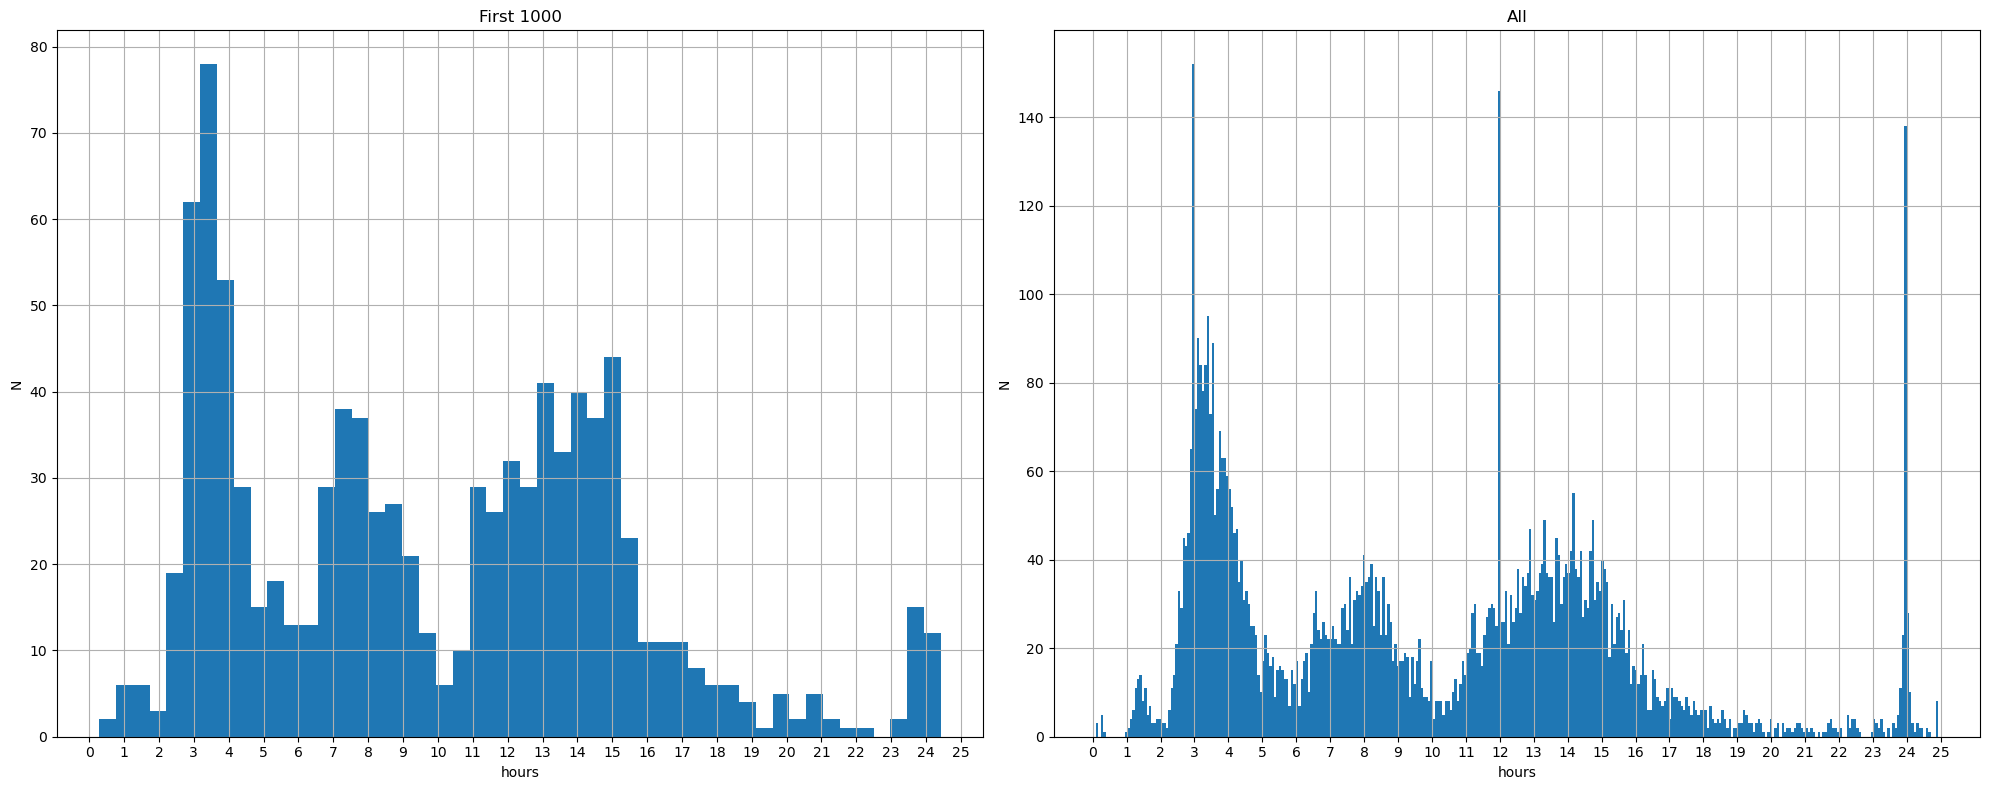

In [ ]:
mask = (results_df['period_hours'] < 25) & (results_df['period_hours'] > 0)
masked = results_df[mask]

first_1000 = results_df.iloc[:1000]
mask_1000 = (first_1000['period_hours'] < 25) & (first_1000['period_hours'] > 0)
first_1000_masked = first_1000[mask_1000]

fig, axes = plt.subplot_mosaic(mosaic='AB', figsize = (20,8))

axes['A'].hist(first_1000_masked['period_hours'], bins=50);
axes['A'].set_title("First 1000")

axes['B'].hist(masked['period_hours'], bins=50*7);
axes['B'].set_title("All")

for ax in axes:
    axes[ax].set_xlabel('hours')
    axes[ax].set_ylabel('N')
    axes[ax].set_xticks(np.arange(0, 26, 1))
    axes[ax].grid()
    
fig.tight_layout()

In the 1000 star histogram, I notice 4 main clusters. The first (~3.5 hours) and third (~13 hours) clusters seem to have a similar number of objects, but the first has a more narrow distribution. The second (~8 hours) cluster seems to be slightly smaller, and the fourth (~24 hours) is much smaller than all of the rest.

Adding the histogram with all of the objects confirms the presence of a cluster with periods ~24 hour. This cluster appears to have an incredibly narrow peak that was not well defined in the first plot. Additionally, this histogram reveals a smaller fifth cluster with periods ~2 hours (the leftmost cluster) that I originally had assumed was part of the cluster with ~4 hour periods. This histogram also shows 2 peaks with similar strength to that from the 24 hour clusters at periods of ~3 and ~12 hours. This could hint at more underlying clusters with narrow distributions.

In [ ]:
df_sorted = masked.sort_values(by='period_hours')

target_values = [3.5, 8, 14, 24]
num_objects = 6
for value in target_values:
    closest_objects = results_df.loc[(results_df['period_hours'] - value).abs().nsmallest(num_objects).index]
    ids = closest_objects.index.tolist()
    results = compute_best_frequencies(dataAll, ids, n_eval=10000, n_retry=5)
    myprettyplot = plot_lightcurves(dataAll, results, ids)

KeyError: 3164

Each peak has a very different collection of plots - there are a few objects between each that have similar plots, but no trend. That being said, all of the peaks expect for the 24 hour one have data points spread fairly evenly across all phases. In the 24 hour plots, there is often a large gap in the phase where there are no data points.

The 3.5 hour peak has the most homogenous set of graphs, each with essentially the same shape but varying amplitudes.

There are similarities between the 8 hour plots (3 of them look like the 3.5 hour plots but noisier), but they vary significantly more than the plots within the 3.5 hour peak. The magnitudes generally change less sharply, and the top left graph has 2 common magnitidues in the middle of its phase.

The 14 peak also is very homogenous within itself. The magnitudes do not change as smoothly as in the previous two peaks, but the shape within these plots (barring the top right plot) is consistent.

The plots in the 24 hour peak are very inconsistent.

## Problem 2

### First obtain data for 6,146 LINEAR stars with confirmed periodic light curves using an astroML built-in function:

In [ ]:
data = fetch_LINEAR_geneva()
# N.B. this is a 7-dimensional dataset, but we use only 4 dimensions
ug = data['ug']
gi = data['gi']
logP = data['logP']
A = data['Ampl']

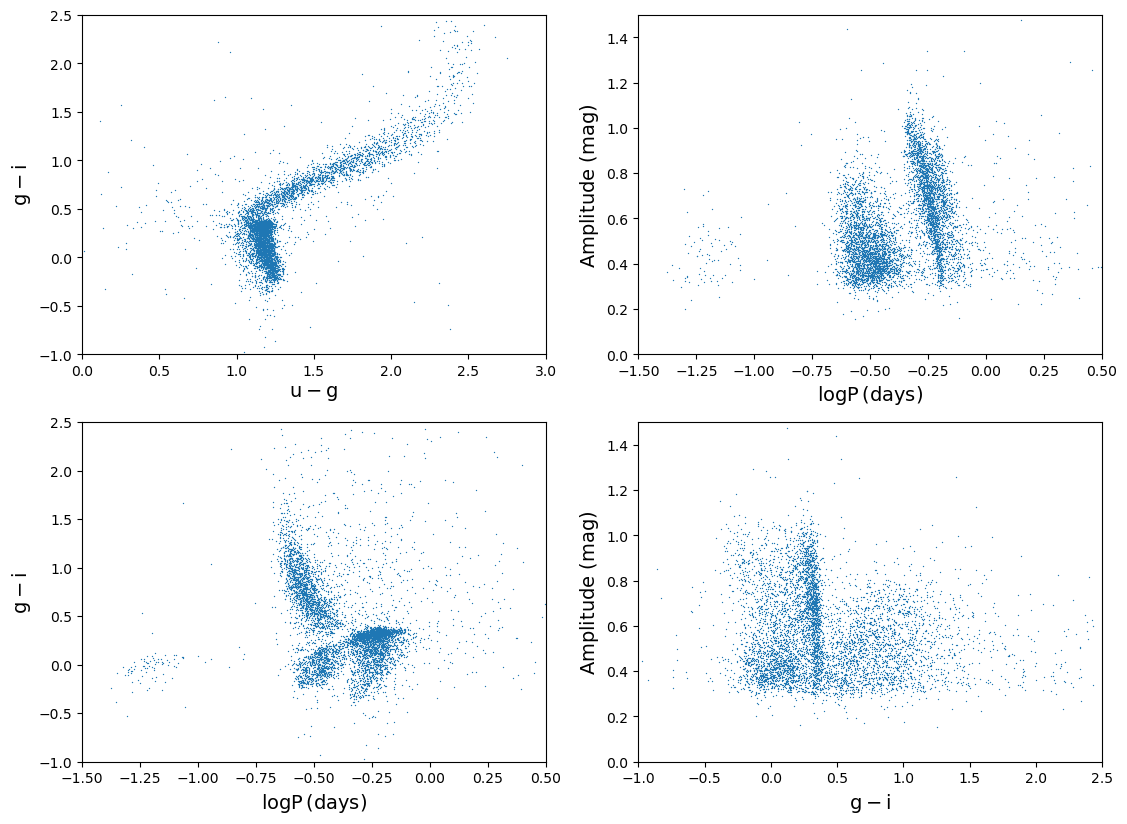

In [ ]:
# set up the plot
fig = plt.figure(figsize=(12, 9), facecolor='w')
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.2, bottom=0.1, top=0.93)

# plot the color-color plot
ax1 = fig.add_subplot(221)
ax1.scatter(ug, gi, s=0.9, lw=0)
ax1.set_xlim(0.0, 3.0)
ax1.set_ylim(-1.0, 2.5)
ax1.set_xlabel(r'${\rm u-g}$', color='k', fontsize=14)
ax1.set_ylabel(r'${\rm g-i}$', color='k', fontsize=14)

# plot the A vs. logP plot
ax2 = fig.add_subplot(222)
ax2.scatter(logP, A, s=0.9, lw=0)
ax2.set_xlim(-1.5, 0.5)
ax2.set_ylim(0.0, 1.5)
ax2.set_xlabel(r'${\rm logP \, (days)}$', color='k', fontsize=14)
ax2.set_ylabel(r'${\rm Amplitude \,\, (mag)}$', color='k', fontsize=14)

# g-i vs. logP
ax3 = fig.add_subplot(223)
ax3.scatter(logP, gi, s=0.9, lw=0)
ax3.set_xlim(-1.5, 0.5)
ax3.set_ylim(-1.0, 2.5)
ax3.set_xlabel(r'${\rm logP \, (days)}$', color='k', fontsize=14)
ax3.set_ylabel(r'${\rm g-i}$', color='k', fontsize=14)

# A vs. g-i 
ax4 = fig.add_subplot(224)
ax4.scatter(gi, A, s=0.9, lw=0)
ax4.set_xlim(-1.0, 2.5)
ax4.set_ylim(0.0, 1.5)
ax4.set_xlabel(r'${\rm g-i}$', color='k', fontsize=14)
ax4.set_ylabel(r'${\rm Amplitude \,\, (mag)}$', color='k', fontsize=14)

plt.show()

## and now do PCA...

In [ ]:
from sklearn.decomposition import PCA

X = np.column_stack((ug, gi, logP, A))

pca = PCA(n_components=4)
pca.fit(X)
evals = pca.explained_variance_ratio_
evals_cs = evals.cumsum()
X_pca = pca.transform(X)

P1 = X_pca[:, 0]
P2 = X_pca[:, 1]
P3 = X_pca[:, 2]
P4 = X_pca[:, 3]

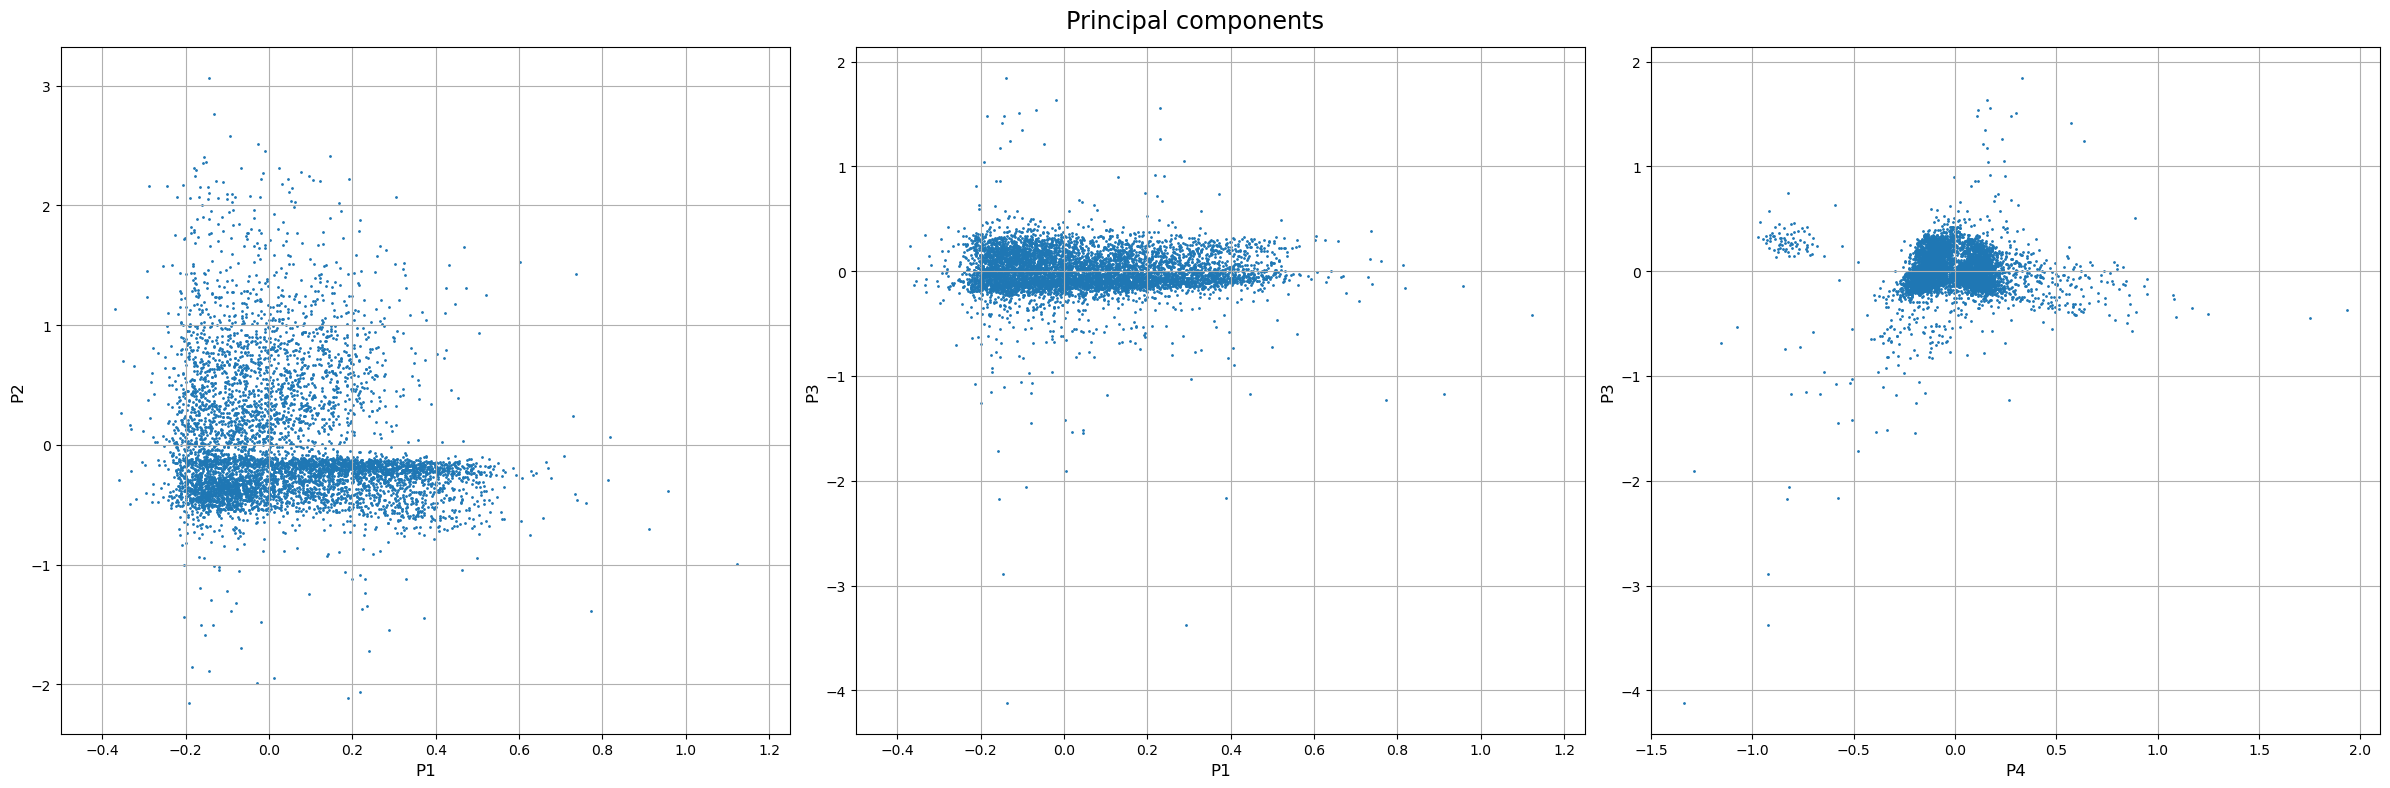

In [ ]:
fig, axes = plt.subplot_mosaic(mosaic='ABC', figsize=(24,8))

axes["A"].scatter(P1, P2, s=1)
axes["A"].set_xlabel('P1', fontsize='large')
axes["A"].set_ylabel('P2', fontsize='large')
axes['A'].set_xlim(-0.5, 1.25) # visualize without outliers

axes["B"].scatter(P1, P3, s=1)
axes["B"].set_xlabel('P1', fontsize='large')
axes["B"].set_ylabel('P3', fontsize='large')
axes['B'].set_xlim(-0.5, 1.25) # visualize without outliers

axes["C"].scatter(P4, P3, s=1)
axes["C"].set_xlabel('P4', fontsize='large')
axes["C"].set_ylabel('P3', fontsize='large')

for ax in axes:
    axes[ax].grid()

fig.suptitle('Principal components', fontsize="xx-large")
fig.tight_layout()

I have two takeaways from the P1+P2 plot. For most vlues of P1, P2 is likely to be around -0.25. However, if P1 is close to zero the P2 values may vary significantly from this (even though most of the values are still grouped around -0.25). 

For any value of P1, P3 is likely going to be around zero. P3 has much lower variance than P1 and they are independent from eachother.

Both P3 and P4 cluster around zero, but there is no clear trend between the two.

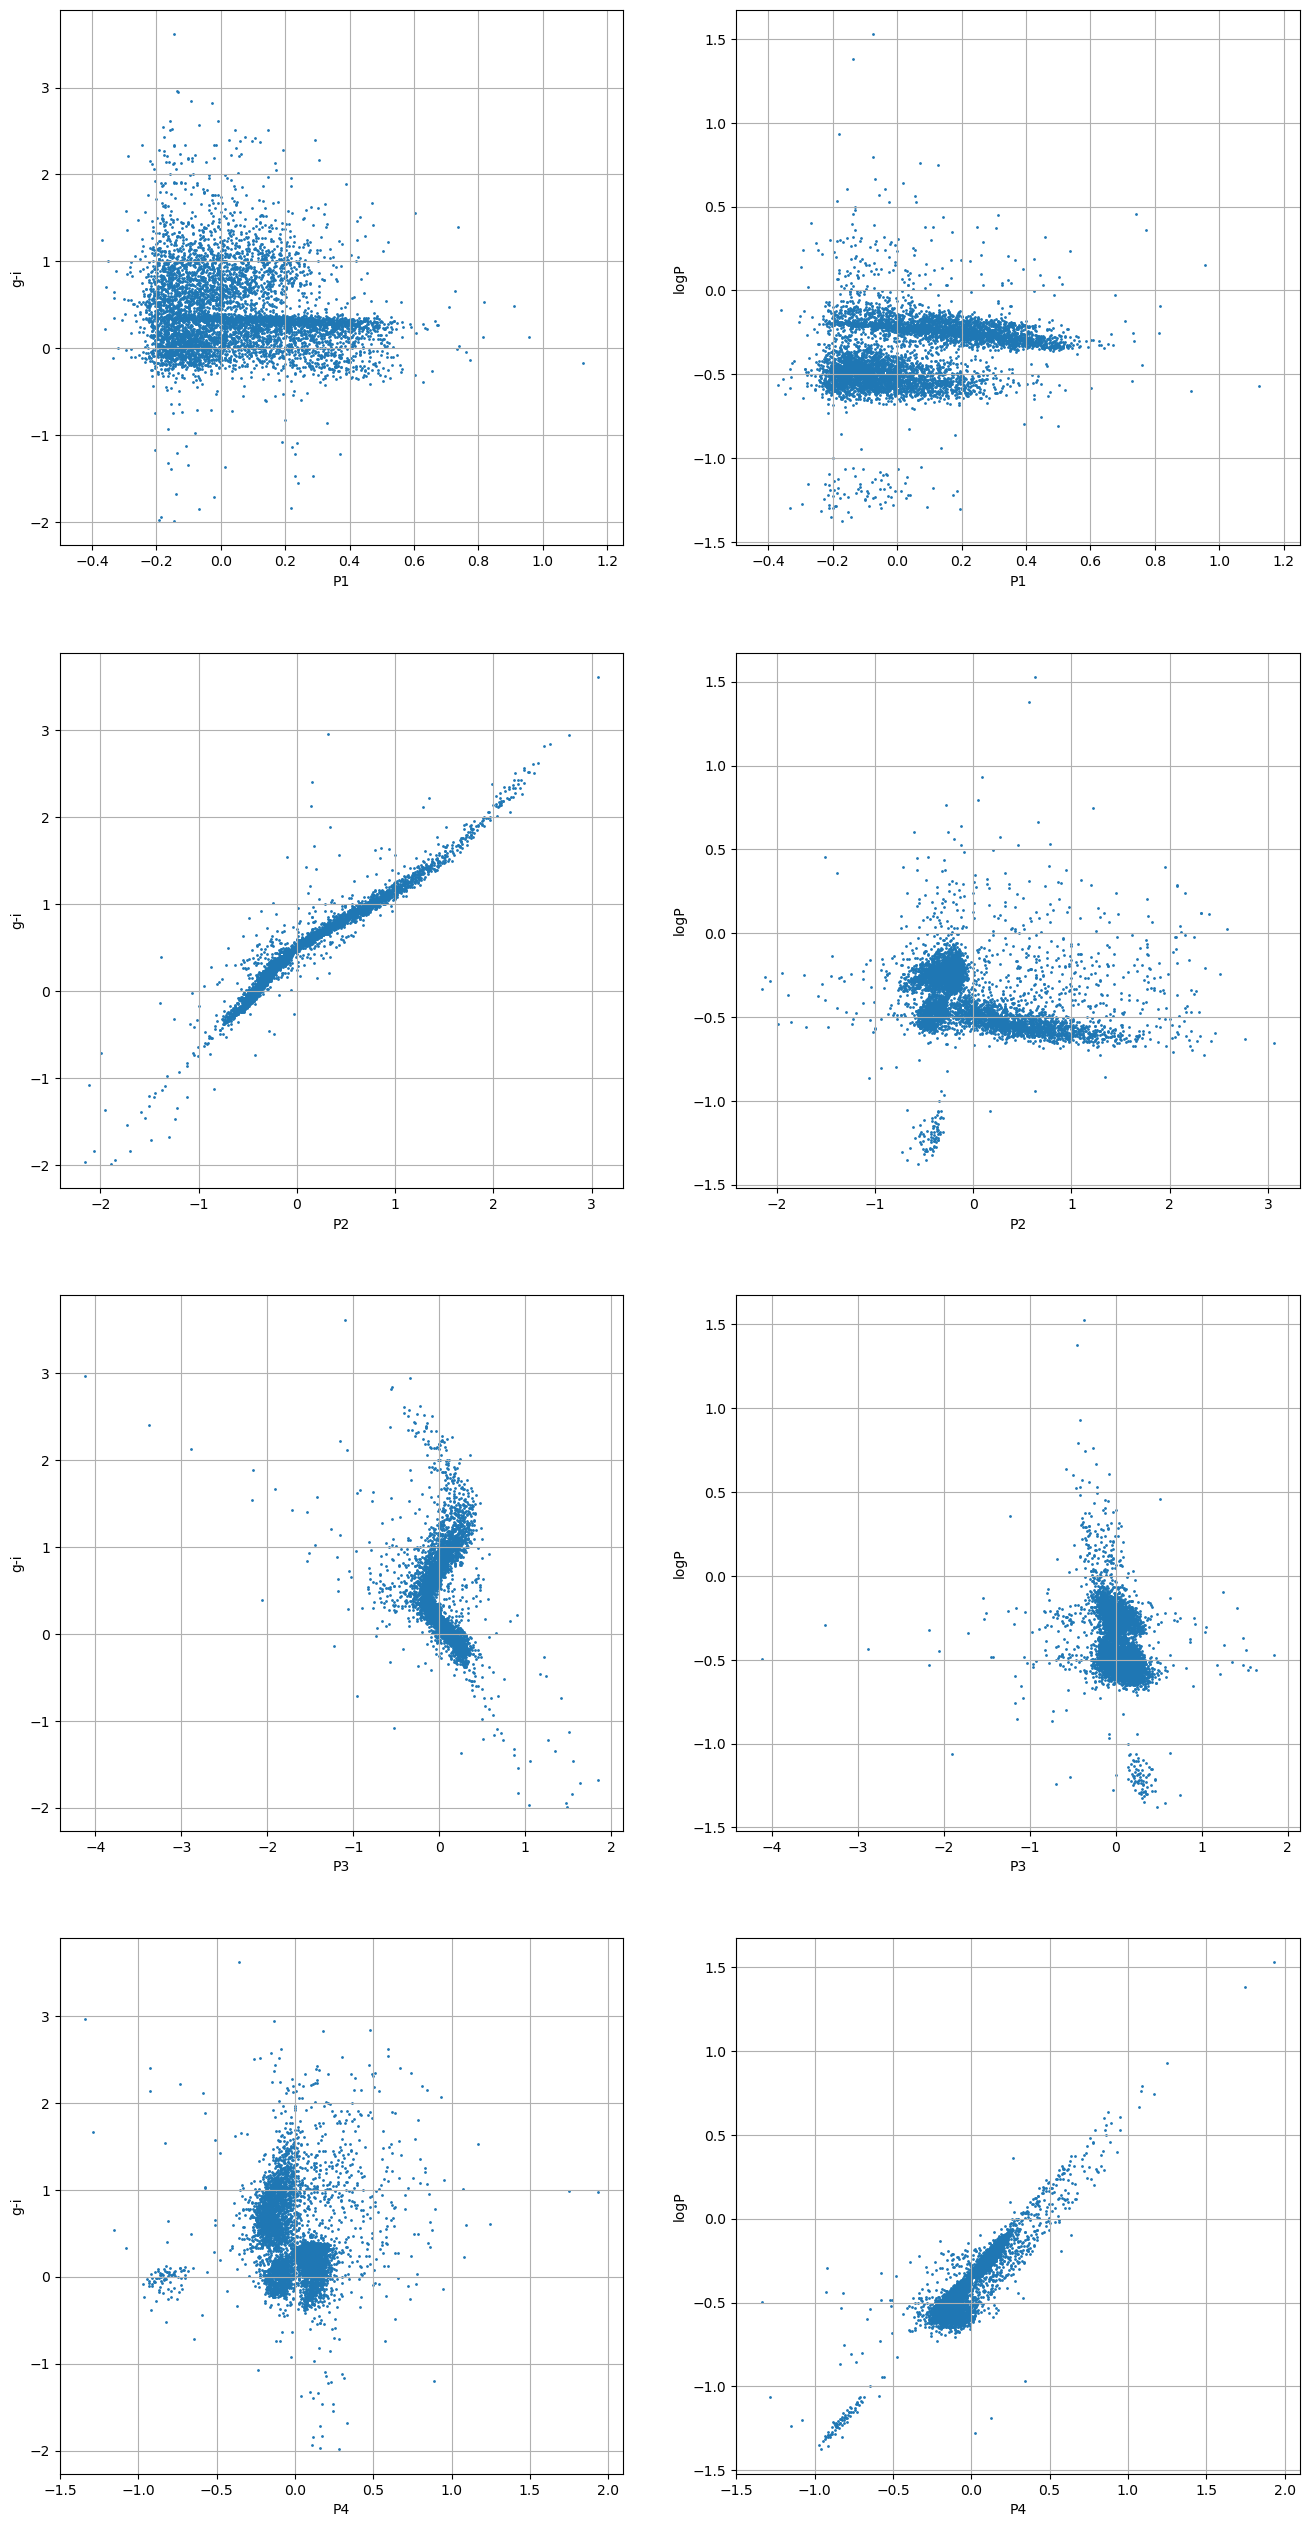

In [ ]:
mosaic = """AB
            CD
            EF
            GH"""

fig, axes = plt.subplot_mosaic(mosaic=mosaic, figsize=(16,32))

axes["A"].scatter(P1, gi, s=1)
axes["A"].set_xlabel('P1')
axes["A"].set_ylabel('g-i')
axes['A'].set_xlim(-0.5, 1.25) # visualize without outliers

axes["B"].scatter(P1, logP, s=1)
axes["B"].set_xlabel('P1')
axes["B"].set_ylabel('logP')
axes['B'].set_xlim(-0.5, 1.25) # visualize without outliers

axes["C"].scatter(P2, gi, s=1)
axes["C"].set_xlabel('P2')
axes["C"].set_ylabel('g-i')

axes["D"].scatter(P2, logP, s=1)
axes["D"].set_xlabel('P2')
axes["D"].set_ylabel('logP')

axes["E"].scatter(P3, gi, s=1)
axes["E"].set_xlabel('P3')
axes["E"].set_ylabel('g-i')

axes["F"].scatter(P3, logP, s=1)
axes["F"].set_xlabel('P3')
axes["F"].set_ylabel('logP')

axes["G"].scatter(P4, gi, s=1)
axes["G"].set_xlabel('P4')
axes["G"].set_ylabel('g-i')

axes["H"].scatter(P4, logP, s=1)
axes["H"].set_xlabel('P4')
axes["H"].set_ylabel('logP')

for ax in axes:
    axes[ax].grid()

There are many insights that can be gathered from these visualizations. Most notably, logP + P4 and P2 + g-i are very strongly correlated. There are less strong but still notable correlations between P1 + logP (which appears bimodal) and P2 + logP.

So, P4 ~ logP, and P2 ~ g-i. From these analyses, if I were to drop one of the dimensions in this data it would be P3 due to its low variance and independence from P1

## Problem 3

## Problem 3

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does PCA stand for, and what does it do?  

Principal component Analysis (PCA) maximizes our ability to discriminate between data points. It linearly transorms data so that components with the largest variation are easy to identify. As these components can largely be used to describe the data, PCA is used to reduce dimensions.

* What does Lomb-Scargle periodogram do? 

It detects periodicity in unvenly spaced observational data. The periodogram shows power (a measure of how good the sin wave fit is) at different frequencies. The frequency of the source (if there is one) will be the freqeuncy where power is maximized.